# Meridian Consumer Goods — Exploratory Data Analysis
## Market Entry Analysis | Analyst: Vinay Wakadkar

### Objective
Explore and understand the cleaned data across all five dimensions before 
building the scoring model. Identify patterns, anomalies, and key insights 
that will inform the market entry recommendation.

### Data Source
SQLite database: `data/database/meridian.db`
ETL pipeline: `scripts/etl.py`

In [1]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plot styling ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# ── Database connection ────────────────────────────────────────
DB_PATH = '../data/database/meridian.db'
conn = sqlite3.connect(DB_PATH)

print("Connected to database successfully")
print(f"SQLite version: {sqlite3.sqlite_version}")

Connected to database successfully
SQLite version: 3.50.4


In [2]:
# ── Data audit — confirm all tables loaded correctly ───────────
query = "SELECT name FROM sqlite_master WHERE type='table'"
tables = pd.read_sql(query, conn)
print("Tables in database:")
print(tables)

print("\nRow counts per table:")
for table in tables['name']:
    count = pd.read_sql(f"SELECT COUNT(*) as rows FROM {table}", conn)
    print(f"  {table}: {count['rows'][0]} rows")

Tables in database:
                       name
0              demographics
1          sec_distribution
2        monthly_indicators
3              store_census
4          channel_coverage
5            infrastructure
6            consumer_spend
7      category_penetration
8   competitor_intelligence
9                 logistics
10                erp_sales

Row counts per table:
  demographics: 3 rows
  sec_distribution: 12 rows
  monthly_indicators: 53 rows
  store_census: 30 rows
  channel_coverage: 162 rows
  infrastructure: 3 rows
  consumer_spend: 324 rows
  category_penetration: 102 rows
  competitor_intelligence: 85 rows
  logistics: 3 rows
  erp_sales: 801 rows


## 1. Database Audit — Confirmed

All 11 tables loaded successfully with expected row counts:
- **3 cities** in demographics, infrastructure, logistics
- **324 rows** of monthly consumer spend across 3 cities × 6 categories × 18 months
- **801 rows** of ERP sales data across 3 reference markets
- **85 rows** of competitor intelligence (some quarters missing for smaller competitors — documented in ETL)
- **53 rows** of monthly macro indicators (Mysuru missing February 2024 — documented in ETL)

No missing tables. Proceeding to exploratory analysis.

In [3]:
# ── Load all tables into dataframes ───────────────────────────
demographics   = pd.read_sql("SELECT * FROM demographics", conn)
sec_dist       = pd.read_sql("SELECT * FROM sec_distribution", conn)
monthly_ind    = pd.read_sql("SELECT * FROM monthly_indicators", conn)
store_census   = pd.read_sql("SELECT * FROM store_census", conn)
channel_cov    = pd.read_sql("SELECT * FROM channel_coverage", conn)
infrastructure = pd.read_sql("SELECT * FROM infrastructure", conn)
consumer_spend = pd.read_sql("SELECT * FROM consumer_spend", conn)
cat_penetration= pd.read_sql("SELECT * FROM category_penetration", conn)
competitors    = pd.read_sql("SELECT * FROM competitor_intelligence", conn)
logistics      = pd.read_sql("SELECT * FROM logistics", conn)
erp            = pd.read_sql("SELECT * FROM erp_sales", conn)

print("All tables loaded into dataframes successfully")

All tables loaded into dataframes successfully


## 2. City Demographics Overview

Understanding the fundamental characteristics of each candidate city — 
population, income, and urbanisation — before any other analysis.

In [4]:
# ── Demographics snapshot ──────────────────────────────────────
print("=== CITY DEMOGRAPHICS SNAPSHOT ===\n")
print(demographics[['city', 'city_population', 'median_hh_income_annual_inr', 
                     'urban_population_pct', 'gdp_growth_rate_pct']].to_string(index=False))

print("\n=== KEY OBSERVATIONS ===")
largest = demographics.loc[demographics['city_population'].idxmax(), 'city']
highest_income = demographics.loc[demographics['median_hh_income_annual_inr'].idxmax(), 'city']
fastest_growth = demographics.loc[demographics['gdp_growth_rate_pct'].idxmax(), 'city']

print(f"  Largest city by population: {largest}")
print(f"  Highest median household income: {highest_income}")
print(f"  Fastest GDP growth: {fastest_growth}")

=== CITY DEMOGRAPHICS SNAPSHOT ===

  city  city_population  median_hh_income_annual_inr  urban_population_pct  gdp_growth_rate_pct
Nashik          1487053                       342000                  70.2                  8.2
Nagpur          2497777                       418000                  75.4                  7.8
Mysuru          1001910                       378000                  68.1                  9.1

=== KEY OBSERVATIONS ===
  Largest city by population: Nagpur
  Highest median household income: Nagpur
  Fastest GDP growth: Mysuru


### Initial Observations — Demographics

- **Nagpur** leads on both population (2.49M) and median household income (₹4.18L) — 
  strongest raw market potential of the three candidates
- **Mysuru** shows highest GDP growth (9.1%) suggesting an expanding market, 
  but smallest absolute population limits near-term volume potential
- **Nashik** is mid-tier across all metrics but proximity to existing Meridian 
  distribution hubs (Mumbai, Pune) may offset weaker demographic indicators
- Initial hypothesis: **Nagpur > Mysuru > Nashik** — subject to revision 
  once competitive landscape and logistics data are incorporated

*Note: Demographics favour Nagpur but high market attractiveness typically 
correlates with stronger incumbent competition — to be verified in Section 4.*

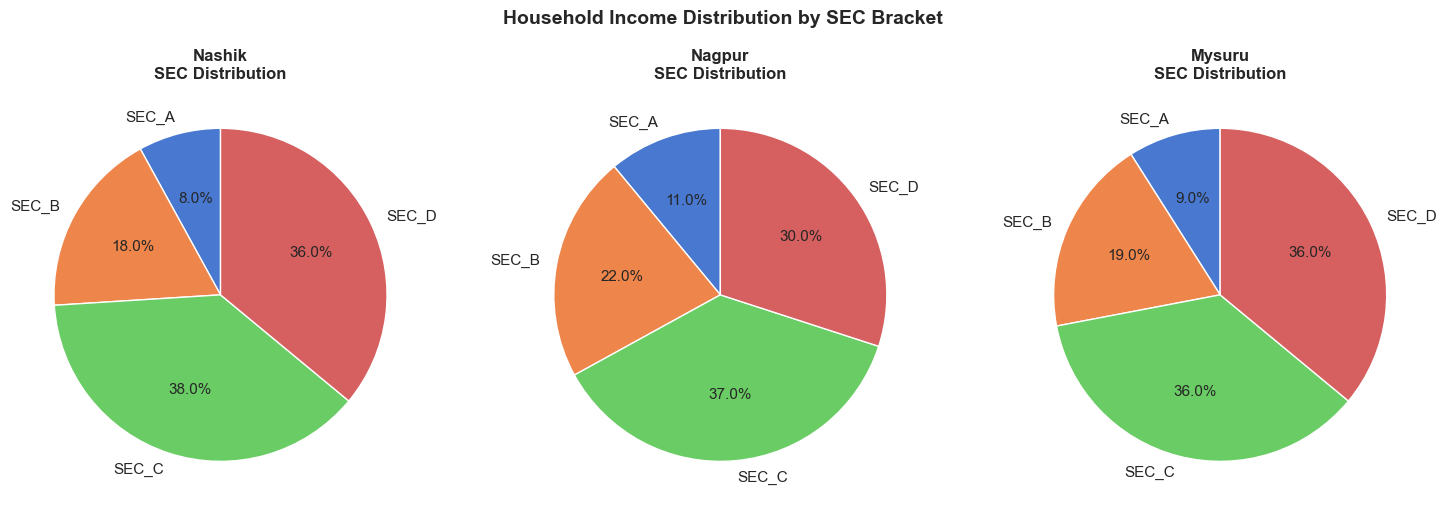


=== SEC DISTRIBUTION TABLE ===
city     Mysuru  Nagpur  Nashik
bracket                        
SEC_A       9.0    11.0     8.0
SEC_B      19.0    22.0    18.0
SEC_C      36.0    37.0    38.0
SEC_D      36.0    30.0    36.0

Target segments for Meridian (SEC B + C combined):
  Nashik: 56.0% of households
  Nagpur: 59.0% of households
  Mysuru: 55.0% of households


In [5]:
# ── SEC income distribution by city ───────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

cities = ['Nashik', 'Nagpur', 'Mysuru']
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, city in enumerate(cities):
    city_data = sec_dist[sec_dist['city'] == city]
    ax[i].pie(
        city_data['share'],
        labels=city_data['bracket'],
        autopct='%1.1f%%',
        colors=sns.color_palette('muted'),
        startangle=90
    )
    ax[i].set_title(f'{city}\nSEC Distribution', fontsize=12, fontweight='bold')

plt.suptitle('Household Income Distribution by SEC Bracket', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print the numbers too
print("\n=== SEC DISTRIBUTION TABLE ===")
sec_pivot = sec_dist.pivot(index='bracket', columns='city', values='share')
print((sec_pivot * 100).round(1).to_string())
print("\nTarget segments for Meridian (SEC B + C combined):")
for city in cities:
    city_data = sec_dist[sec_dist['city'] == city]
    target = city_data[city_data['bracket'].isin(['SEC_B', 'SEC_C'])]['share'].sum()
    print(f"  {city}: {target*100:.1f}% of households")

### SEC Income Distribution Analysis

- Nagpur has the largest share of Meridian's target segments (SEC B+C = 59%) 
  AND the largest absolute population — compounding advantage
- Nashik and Mysuru are close on SEC B+C share (56% vs 55%) but Nashik's 
  larger population gives it a bigger absolute addressable market
- SEC D is highest in Nashik and Mysuru (36% each) vs Nagpur (30%) — 
  suggesting stronger value-brand competition in those markets
- **Revised hypothesis: Nagpur > Nashik >= Mysuru**
- Logistics and competitive landscape data required before finalising

*Mysuru's higher GDP growth and income partially offset its smaller 
addressable market — timing of entry could be a differentiating factor.*

## 3. Consumer Spending Analysis

Examining household FMCG spending patterns across cities and categories.
This directly informs Total Addressable Market calculations in the financial model.

=== TOTAL MONTHLY HH SPEND PER CITY (ALL CATEGORIES) ===
  city  total_monthly_spend_inr
Nagpur                    80573
Mysuru                    66413
Nashik                    66342


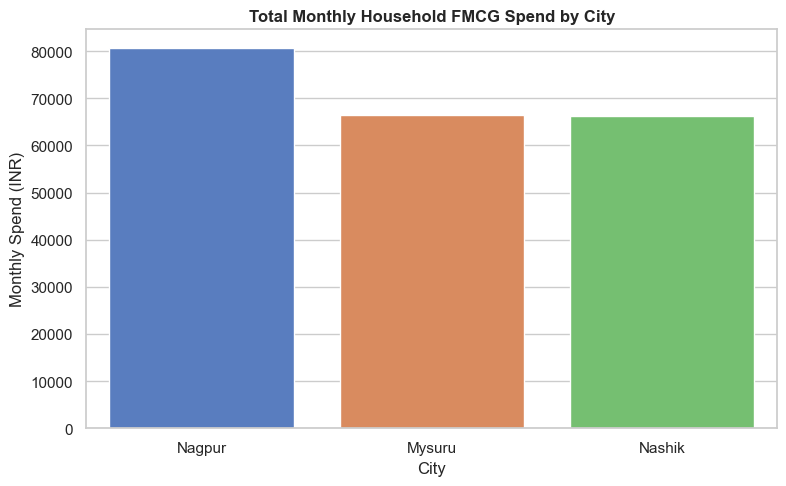

In [6]:
# ── Total monthly spend per city across all categories ─────────
city_spend = consumer_spend.groupby('city')['avg_hh_spend_monthly_inr'].sum().reset_index()
city_spend.columns = ['city', 'total_monthly_spend_inr']
city_spend = city_spend.sort_values('total_monthly_spend_inr', ascending=False)

print("=== TOTAL MONTHLY HH SPEND PER CITY (ALL CATEGORIES) ===")
print(city_spend.to_string(index=False))

# ── Bar chart ──────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.barplot(data=city_spend, x='city', y='total_monthly_spend_inr', palette='muted')
plt.title('Total Monthly Household FMCG Spend by City', fontweight='bold')
plt.xlabel('City')
plt.ylabel('Monthly Spend (INR)')
plt.tight_layout()
plt.show()

### Consumer Spending Observations

- Nagpur leads total monthly HH spend at ₹80,573 — 21% higher than both 
  other cities, compounding its population advantage into a larger absolute market
- Mysuru and Nashik are nearly identical at household level (₹66,413 vs ₹66,342) 
  — surprising given Nashik's larger population and lower median income
- Mysuru's higher spend despite lower population suggests stronger per-household 
  FMCG consumption — consistent with its higher literacy and urban sophistication
- **Hypothesis update: Nagpur remains clear leader. Mysuru vs Nashik decision 
  now depends heavily on logistics costs and competitive intensity**

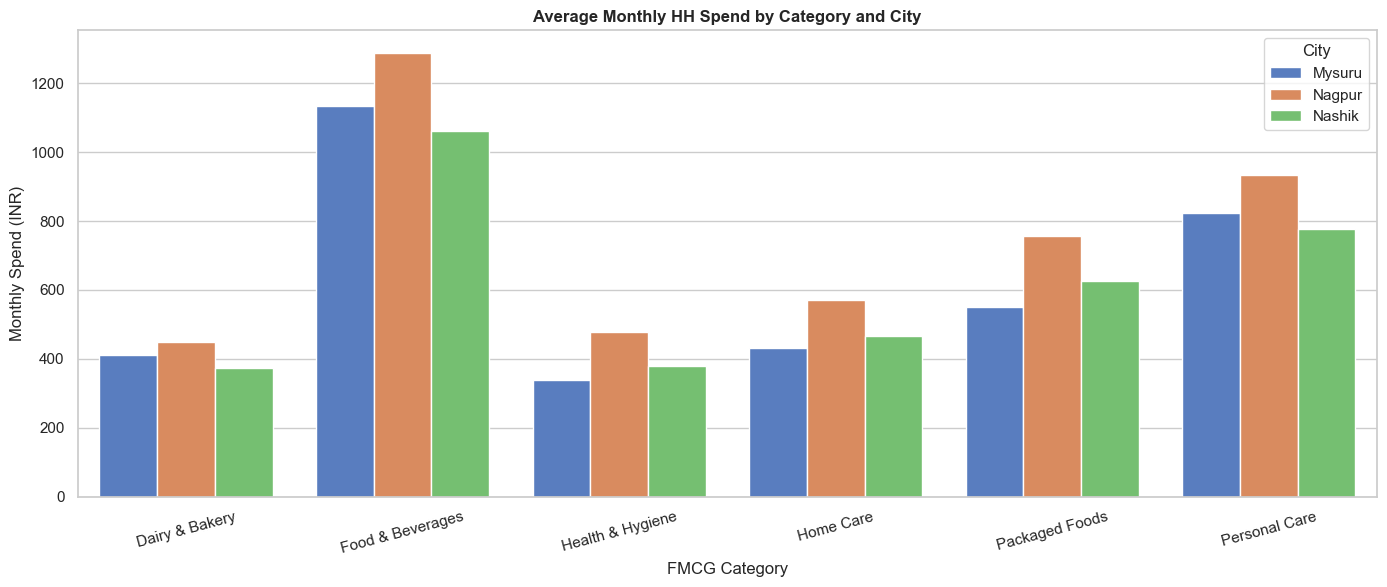


=== CATEGORY SPEND BY CITY (AVG MONTHLY INR) ===
city              Mysuru  Nagpur  Nashik
fmcg_category                           
Dairy & Bakery     410.0   449.0   375.0
Food & Beverages  1132.0  1288.0  1062.0
Health & Hygiene   340.0   477.0   380.0
Home Care          433.0   572.0   468.0
Packaged Foods     551.0   757.0   625.0
Personal Care      823.0   933.0   776.0


In [7]:
# ── Category-wise spend comparison across cities ───────────────
cat_spend = consumer_spend.groupby(['city', 'fmcg_category'])['avg_hh_spend_monthly_inr'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=cat_spend, x='fmcg_category', y='avg_hh_spend_monthly_inr', 
            hue='city', palette='muted')
plt.title('Average Monthly HH Spend by Category and City', fontweight='bold')
plt.xlabel('FMCG Category')
plt.ylabel('Monthly Spend (INR)')
plt.xticks(rotation=15)
plt.legend(title='City')
plt.tight_layout()
plt.show()

# Print the numbers
print("\n=== CATEGORY SPEND BY CITY (AVG MONTHLY INR) ===")
cat_pivot = cat_spend.pivot(index='fmcg_category', columns='city', values='avg_hh_spend_monthly_inr')
print(cat_pivot.round(0).to_string())

### Category Spending Analysis

- Food & Beverages is the highest spend category across all three cities — 
  primary launch category for Meridian's market entry
- Personal Care is consistently second — strong candidate for simultaneous launch
- Nagpur leads across almost all categories, confirming it as the strongest 
  overall market
- Mysuru and Nashik are close across most categories — category-specific 
  logistics requirements may be the deciding factor between them
- **Strategic implication: Lead with Food & Beverages and Personal Care in 
  the entry city. Cold chain requirement for F&B makes Nashik a safer second 
  market than Mysuru if Nagpur is selected first**
- Competitor saturation in high-spend categories to be verified in Section 4

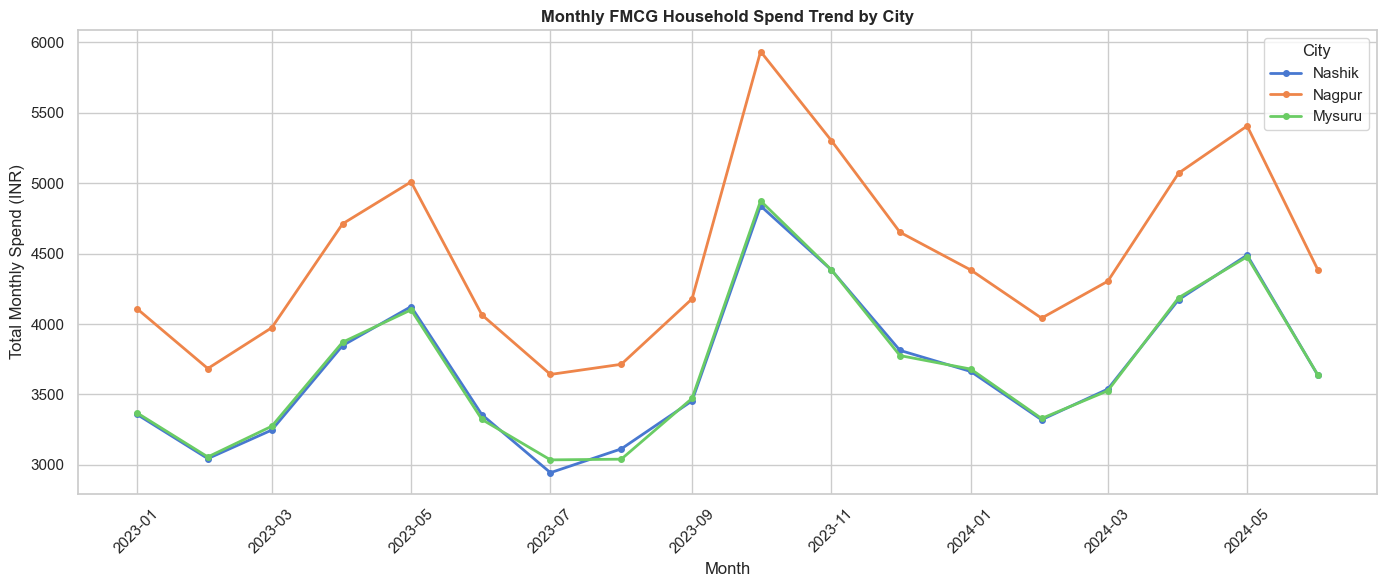


=== TOP 3 PEAK SPEND MONTHS PER CITY ===
  Nashik: Oct-2023, May-2024, Nov-2023
  Nagpur: Oct-2023, May-2024, Nov-2023
  Mysuru: Oct-2023, May-2024, Nov-2023


In [8]:
# ── Monthly spend trends over time ─────────────────────────────
# Aggregate total spend across all categories per city per month
spend_trend = consumer_spend.groupby(['city', 'period'])['avg_hh_spend_monthly_inr'].sum().reset_index()
spend_trend['period'] = pd.to_datetime(spend_trend['period'])
spend_trend = spend_trend.sort_values(['city', 'period'])

plt.figure(figsize=(14, 6))
for city in ['Nashik', 'Nagpur', 'Mysuru']:
    city_data = spend_trend[spend_trend['city'] == city]
    plt.plot(city_data['period'], city_data['avg_hh_spend_monthly_inr'], 
             marker='o', markersize=4, label=city, linewidth=2)

plt.title('Monthly FMCG Household Spend Trend by City', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Monthly Spend (INR)')
plt.legend(title='City')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── Identify peak months ───────────────────────────────────────
print("\n=== TOP 3 PEAK SPEND MONTHS PER CITY ===")
for city in ['Nashik', 'Nagpur', 'Mysuru']:
    city_data = spend_trend[spend_trend['city'] == city].nlargest(3, 'avg_hh_spend_monthly_inr')
    peaks = city_data['period'].dt.strftime('%b-%Y').tolist()
    print(f"  {city}: {', '.join(peaks)}")

### Spending Trends and Seasonality

- Clear seasonal pattern visible across all three cities — wave-like trend 
  with consistent peaks
- **Peak months: October > May > November**
  - October-November: Diwali festive season — Personal Care and Packaged 
    Foods gifting drives spike
  - May: Summer peak — Food & Beverages and Health & Hygiene demand surge
- Seasonality is consistent across all three cities — not city-specific, 
  reflects national FMCG consumption patterns
- **Strategic implication for market entry timing: Launch by August at latest 
  to establish distribution before Diwali. Missing the October peak in Year 1 
  would materially impact revenue projections**
- Financial model must incorporate seasonal multipliers — flat monthly 
  projections would underestimate peak months and overestimate off-peak months

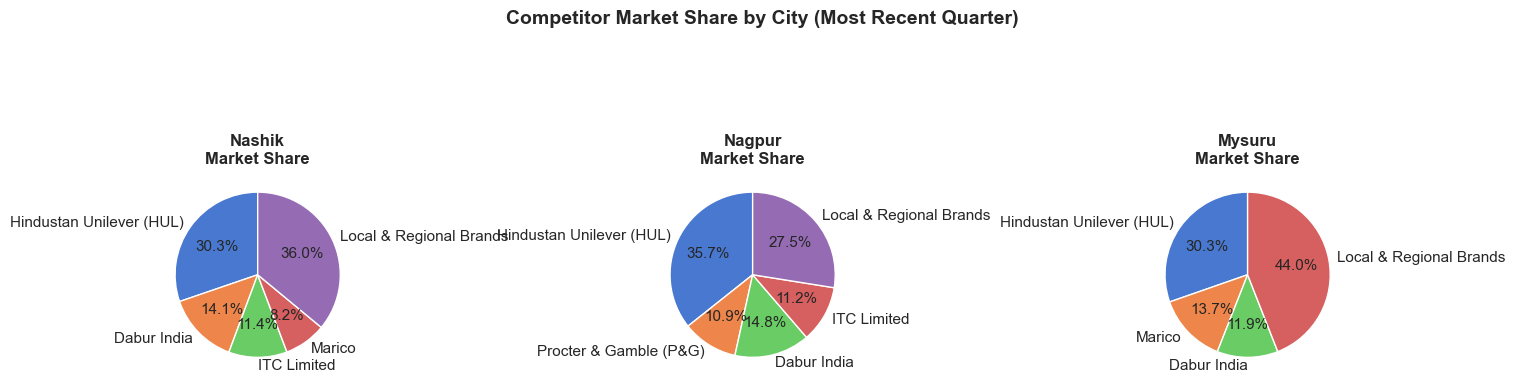


=== COMPETITOR MARKET SHARE BY CITY ===
city                      Mysuru  Nagpur  Nashik
competitor                                      
Dabur India                 11.9    14.8    14.1
Hindustan Unilever (HUL)    30.3    35.7    30.3
ITC Limited                  NaN    11.2    11.4
Local & Regional Brands     44.0    27.5    36.0
Marico                      13.7     NaN     8.2
Procter & Gamble (P&G)       NaN    10.9     NaN

=== HUL MARKET SHARE ACROSS CITIES ===
  Nashik: 30.3%
  Nagpur: 35.7%
  Mysuru: 30.3%


In [9]:
# ── Competitor market share by city ───────────────────────────
# Use most recent quarter available per city
latest_quarter = competitors.groupby('city')['quarter'].max().reset_index()
latest_quarter.columns = ['city', 'latest_quarter']
recent_comp = competitors.merge(latest_quarter, on=['city'])
recent_comp = recent_comp[recent_comp['quarter'] == recent_comp['latest_quarter']]

plt.figure(figsize=(15, 5))
for i, city in enumerate(['Nashik', 'Nagpur', 'Mysuru']):
    ax = plt.subplot(1, 3, i+1)
    city_data = recent_comp[recent_comp['city'] == city]
    ax.pie(
        city_data['market_share_normalised'],
        labels=city_data['competitor'],
        autopct='%1.1f%%',
        colors=sns.color_palette('muted'),
        startangle=90
    )
    ax.set_title(f'{city}\nMarket Share', fontweight='bold')

plt.suptitle('Competitor Market Share by City (Most Recent Quarter)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print numbers
print("\n=== COMPETITOR MARKET SHARE BY CITY ===")
share_pivot = recent_comp.pivot_table(
    index='competitor', 
    columns='city', 
    values='market_share_normalised',
    aggfunc='mean'
).round(3) * 100
print(share_pivot.to_string())

# ── HUL dominance analysis ─────────────────────────────────────
print("\n=== HUL MARKET SHARE ACROSS CITIES ===")
hul = recent_comp[recent_comp['competitor'] == 'Hindustan Unilever (HUL)']
for _, row in hul.iterrows():
    print(f"  {row['city']}: {row['market_share_normalised']*100:.1f}%")

### Competitor Landscape Analysis

- **Nagpur: most competitive market** — HUL at 35.7%, every competitor 
  above 10% share. Limited room for a new entrant without significant 
  BTL investment. High entry cost, longer breakeven likely.
- **Nashik: moderate competition** — HUL at 30%, but 38% local/regional 
  brand share indicates underpenetrated organised FMCG market. 
  Room for a credible national brand to capture switching customers.
- **Mysuru: least competitive** — only 4 competitors, HUL at 30%, 
  local brands dominating at 44%. Strongest penetration opportunity 
  but cold chain gap is a material operational risk.

**Hypothesis fully revised: Nashik > Mysuru > Nagpur**

Reasoning:
- Nashik: logistics advantage (₹2,800/MT, 4.5hrs from Mumbai), cold chain 
  available, moderate competition, existing distribution infrastructure nearby
- Mysuru: easiest market penetration, fastest GDP growth, but cold chain 
  gap and distance (22hrs, ₹7,800/MT) require higher Year 1 investment
- Nagpur: largest market but most entrenched competition — entry cost 
  likely exceeds budget without disproportionate marketing spend

*Note: Nagpur remains viable if Board increases Year 1 capex beyond ₹12 crore. 
At current ₹8-12 crore budget, Nashik is the most financially defensible choice.*

=== LOGISTICS OVERVIEW ===

  city  Distance_km  Avg_Transit_hrs_from_Mumbai Total_Logistics_Cost_INR_per_MT Cost_per_sqft_monthly_INR  Last_Mile_Index_10 Stockout_Risk
Nashik          180                          4.5                            3420                        28                 7.2        Medium
Nagpur          872                         14.0                            6010                        22                 8.4           Low
Mysuru         1289                         22.0                            8940                        32                 6.1          High


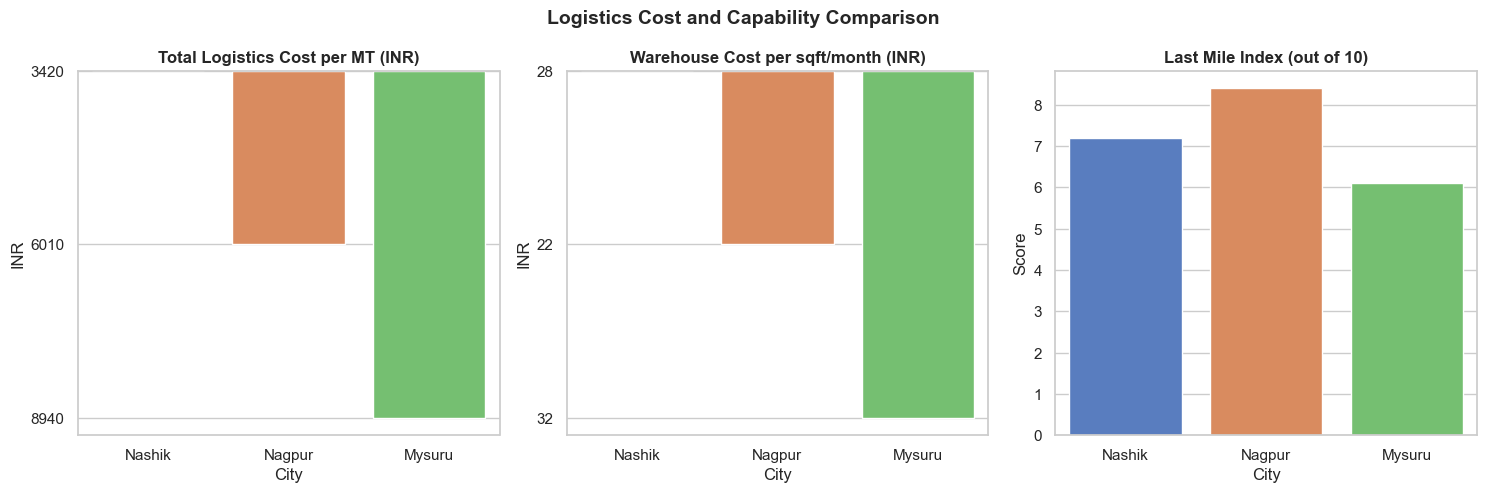


=== LOGISTICS COST INDEX (Nashik = 100) ===
  Nashik: 100 (stockout risk: Medium)
  Nagpur: 176 (stockout risk: Low)
  Mysuru: 261 (stockout risk: High)


In [10]:
# ── Logistics comparison across cities ────────────────────────
print("=== LOGISTICS OVERVIEW ===\n")
print(logistics[['city', 'Distance_km', 'Avg_Transit_hrs_from_Mumbai',
                 'Total_Logistics_Cost_INR_per_MT', 'Cost_per_sqft_monthly_INR',
                 'Last_Mile_Index_10', 'Stockout_Risk']].to_string(index=False))

# ── Cost comparison chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=logistics, x='city', y='Total_Logistics_Cost_INR_per_MT', 
            palette='muted', ax=axes[0])
axes[0].set_title('Total Logistics Cost per MT (INR)', fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('INR')

sns.barplot(data=logistics, x='city', y='Cost_per_sqft_monthly_INR', 
            palette='muted', ax=axes[1])
axes[1].set_title('Warehouse Cost per sqft/month (INR)', fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('INR')

sns.barplot(data=logistics, x='city', y='Last_Mile_Index_10', 
            palette='muted', ax=axes[2])
axes[2].set_title('Last Mile Index (out of 10)', fontweight='bold')
axes[2].set_xlabel('City')
axes[2].set_ylabel('Score')

plt.suptitle('Logistics Cost and Capability Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

logistics['Total_Logistics_Cost_INR_per_MT'] = pd.to_numeric(
    logistics['Total_Logistics_Cost_INR_per_MT'], errors='coerce'
)

# ── Cost index against Nashik as base ─────────────────────────
print("\n=== LOGISTICS COST INDEX (Nashik = 100) ===")
nashik_freight = logistics[logistics['city'] == 'Nashik']['Total_Logistics_Cost_INR_per_MT'].values[0]
for _, row in logistics.iterrows():
    index = (row['Total_Logistics_Cost_INR_per_MT'] / nashik_freight) * 100
    print(f"  {row['city']}: {index:.0f} (stockout risk: {row['Stockout_Risk']})")

## 4. ERP Sales Analysis — Reference Market Benchmarking

Analysing Meridian's performance in existing markets (Mumbai, Pune, Aurangabad)
to build realistic revenue projection benchmarks for the entry city financial model.
Aurangabad is the most relevant benchmark — closest in size and tier to our candidate cities.

=== TOTAL REVENUE BY MARKET (18 MONTHS) ===
    market  gross_revenue_inr
    Mumbai         1132758675
      Pune          362998875
Aurangabad          148187275


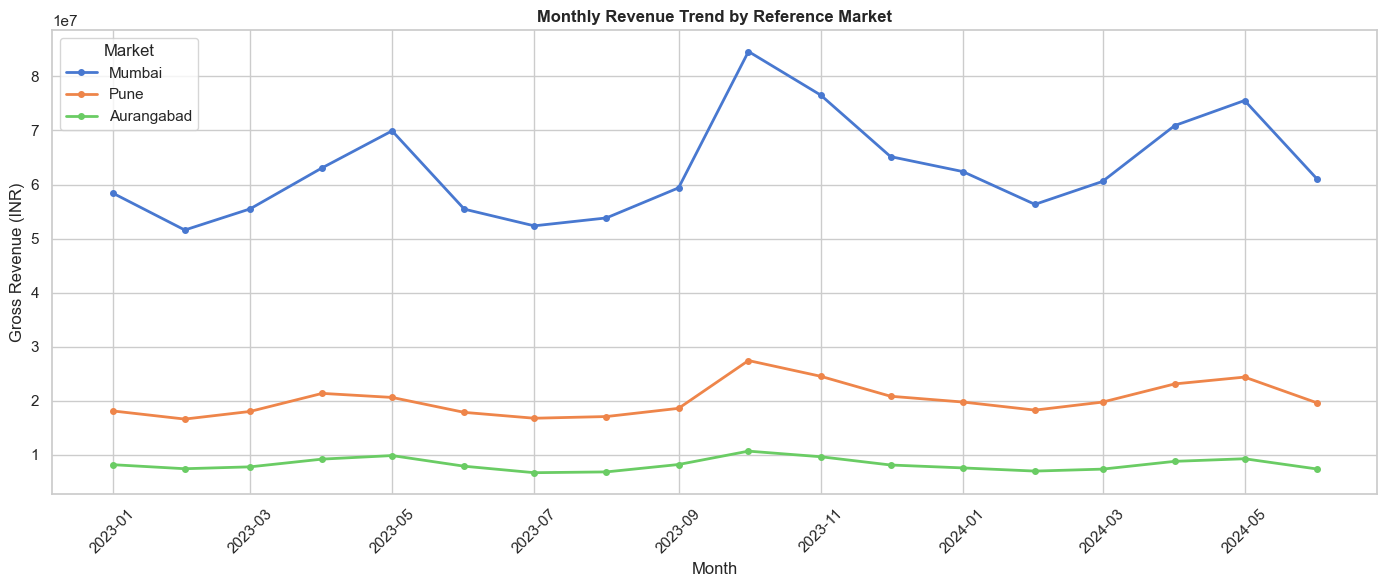

In [11]:
# ── Total revenue by market ────────────────────────────────────
market_revenue = erp.groupby('market')['gross_revenue_inr'].sum().reset_index()
market_revenue = market_revenue.sort_values('gross_revenue_inr', ascending=False)

print("=== TOTAL REVENUE BY MARKET (18 MONTHS) ===")
print(market_revenue.to_string(index=False))

# ── Monthly revenue trend ──────────────────────────────────────
erp['date'] = pd.to_datetime(erp['date'])
monthly_rev = erp.groupby(['market', 'date'])['gross_revenue_inr'].sum().reset_index()

plt.figure(figsize=(14, 6))
for market in ['Mumbai', 'Pune', 'Aurangabad']:
    data = monthly_rev[monthly_rev['market'] == market]
    plt.plot(data['date'], data['gross_revenue_inr'],
             marker='o', markersize=4, label=market, linewidth=2)

plt.title('Monthly Revenue Trend by Reference Market', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Gross Revenue (INR)')
plt.legend(title='Market')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ERP Reference Market Analysis

- Mumbai at ₹113.3 crore and Pune at ₹36.3 crore over 18 months reflect 
  mature, established markets — not appropriate benchmarks for new city entry
- **Aurangabad at ₹14.8 crore is the primary benchmark** — Tier 2 city, 
  comparable demographics, actual Meridian performance data
- Aurangabad line appears flatter than other markets due to:
  - Smaller absolute volume amplifying seasonal spikes less visibly
  - Stockout events in Jul-Aug 2023 disrupting natural demand curve
  - FB002 discontinuation after Sep 2023 reducing SKU count
- **Revenue projection assumption for Nashik entry:**
  - Month 1-6: 60-70% of Aurangabad steady-state monthly revenue 
    (distribution ramp-up period)
  - Month 7-12: 80-90% of Aurangabad (distribution depth building)
  - Month 13+: Aurangabad parity or above (brand established)
- Exact ramp curve to be modelled in financial model with base/optimistic/
  conservative scenarios

=== AURANGABAD REVENUE BY CATEGORY (18 MONTHS) ===
        category  gross_revenue_inr
   Personal Care           62445420
       Home Care           31950285
Food & Beverages           25968440
Health & Hygiene           17555530
  Packaged Foods           10267600


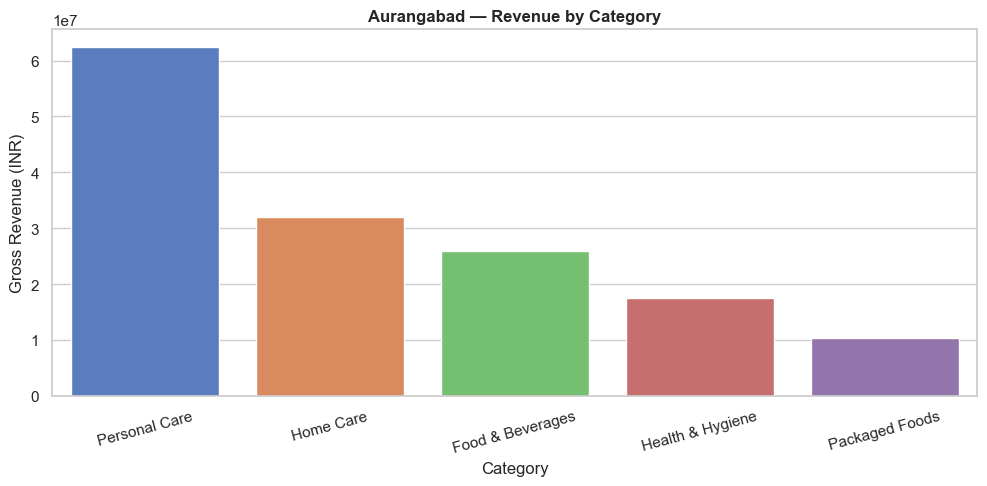


=== TOP 10 SKUs IN AURANGABAD BY REVENUE ===
                      sku_name         category  gross_revenue_inr
        Meridian Shampoo 200ml    Personal Care           23490720
       Meridian Fruit Juice 1L Food & Beverages           13624710
       Meridian Face Wash 100g    Personal Care           13374600
    Meridian Conditioner 150ml    Personal Care           13138020
     Meridian Floor Cleaner 1L        Home Care           13051920
    Meridian Body Lotion 250ml    Personal Care           12442080
      Meridian Dish Wash 500ml        Home Care           11820330
Meridian Breakfast Cereal 400g Food & Beverages            9144800
     Meridian Antiseptic 250ml Health & Hygiene            7583290
 Meridian Hand Sanitizer 100ml Health & Hygiene            7434900

=== STOCKOUT EVENTS IN AURANGABAD ===
  Total stockout instances: 2
      date                 sku_name  units_sold
2023-07-01 Meridian Dish Wash 500ml           0
2023-08-01 Meridian Dish Wash 500ml           0


In [12]:
# ── SKU performance in Aurangabad — primary benchmark ─────────
aur = erp[erp['market'] == 'Aurangabad'].copy()

# Revenue by category
cat_rev = aur.groupby('category')['gross_revenue_inr'].sum().reset_index()
cat_rev = cat_rev.sort_values('gross_revenue_inr', ascending=False)

print("=== AURANGABAD REVENUE BY CATEGORY (18 MONTHS) ===")
print(cat_rev.to_string(index=False))

# ── Category revenue chart ─────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.barplot(data=cat_rev, x='category', y='gross_revenue_inr', palette='muted')
plt.title('Aurangabad — Revenue by Category', fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Gross Revenue (INR)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ── Top SKUs by revenue ────────────────────────────────────────
sku_rev = aur.groupby(['sku_code', 'sku_name', 'category'])['gross_revenue_inr'].sum().reset_index()
sku_rev = sku_rev.sort_values('gross_revenue_inr', ascending=False).head(10)

print("\n=== TOP 10 SKUs IN AURANGABAD BY REVENUE ===")
print(sku_rev[['sku_name', 'category', 'gross_revenue_inr']].to_string(index=False))

# ── Stockout analysis ──────────────────────────────────────────
stockouts = aur[aur['stockout_flag'] == 'Y']
print(f"\n=== STOCKOUT EVENTS IN AURANGABAD ===")
print(f"  Total stockout instances: {len(stockouts)}")
print(stockouts[['date', 'sku_name', 'units_sold']].to_string(index=False))

### SKU Performance Analysis — Aurangabad Benchmark

- **Personal Care dominates Aurangabad revenue** — contrasts with Nielsen 
  data showing Food & Beverages as highest spend category overall
  - Explanation: Nielsen captures total category spend across all brands. 
    Meridian's competitive strength lies specifically in Personal Care SKUs
  - Meridian Shampoo 200ml is top SKU — nearly double second-ranked product
  - Implication: Personal Care should lead Nashik launch, not Food & Beverages

- **Home Care is second — stronger than Nielsen data suggested**
  - Dish Wash 500ml stockout in Jul-Aug 2023 suppresses its true revenue rank
  - Zero sales during stockout = supply failure, not demand failure
  - Actual demand is higher than revenue numbers indicate
  - Home Care is an underestimated category for Tier 2 market entry

- **Food & Beverages ranks third despite being highest Nielsen spend category**
  - Meridian's F&B SKUs face stronger competition from HUL and local brands
  - Lower competitive advantage in this category vs Personal Care

**SKU launch priority for Nashik entry:**
1. Personal Care — lead with Shampoo 200ml and Face Wash 100g
2. Home Care — Dish Wash 500ml shows strong demand signal
3. Food & Beverages — secondary launch after distribution established

## 5. EDA Summary — Consolidated Findings

In [17]:
### Evidence-Based City Ranking After Exploratory Analysis

| Dimension | Nashik | Nagpur | Mysuru |
|---|---|---|---|
| Population & Demographics | Medium | Strong | Weak |
| SEC B+C Addressable Market | Medium | Strong | Medium |
| Consumer Spending per HH | Medium | Strong | Medium |
| Seasonality & Growth | Medium | Medium | Strong |
| Competitive Intensity | Medium | Weak | Strong |
| Logistics Cost | Strong | Medium | Weak |
| Last Mile & Reliability | Medium | Strong | Weak |
| SKU Benchmark Fit | Strong | Medium | Unknown |

### Final EDA Hypothesis

**Recommended city: Nashik**

Nashik emerges as the most balanced entry point across all dimensions. 
It does not lead on any single metric but has no critical weaknesses
unlike Nagpur (competition) and Mysuru (logistics and cold chain).

Key supporting evidence:
- Lowest logistics cost at INR 3,420/MT - 2.6x cheaper than Mysuru
- Cold chain available - enables full Personal Care SKU rollout
- 38% local brand share indicates underpenetrated organised FMCG market
- Proximity to Mumbai and Pune plants reduces supply chain risk
- Aurangabad benchmark (comparable Tier 2 Maharashtra city) shows 
  Personal Care and Home Care as strongest Meridian categories 
  both viable in Nashik without infrastructure constraints

**Alternative: Nagpur** - viable if Board increases capex above ₹12 crore 
and accepts higher competitive intensity requiring stronger BTL investment.

**Phase 2: Mysuru** - recommended as second city entry in FY2026-27 after 
Nashik establishes distribution. Cold chain investment justified once 
Meridian has Maharashtra cash flow supporting Karnataka expansion.

### Key Assumptions Carried Forward to Financial Model
- Revenue ramp: 60-70% of Aurangabad steady-state in Month 1-6
- Seasonal multipliers applied - October peak at 38% above baseline
- Personal Care leads SKU rollout, Home Care secondary
- Logistics cost: INR 3,420/MT (Nashik total)
- Warehouse: INR 28/sqft/month, 3rd party arrangement
- Breakeven target: within 18 months (per Aurangabad pilot precedent)

SyntaxError: invalid decimal literal (186817720.py, line 23)